<a href="https://colab.research.google.com/github/khumairaaalatifa97-ctrl/tugas-mandiri-praktikum-4/blob/main/bab4_praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Khumaira Latifa Nim : 230705107 Mk : Kecerdasan buatan

In [47]:
import re

In [48]:
import numpy as np

In [49]:
import pandas as pd

In [50]:
import matplotlib.pyplot as plt

In [51]:
import seaborn as sns

In [52]:
import tensorflow as tf

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
from sklearn.utils import class_weight

In [55]:
from sklearn.metrics import confusion_matrix

In [56]:
from nltk.tokenize import word_tokenize

In [57]:
from keras.preprocessing import sequence

In [58]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [59]:
from keras.preprocessing import sequence

In [60]:
from keras.layers import Input, Dense, LSTM, Dropout, concatenate

In [61]:
from tensorflow.keras.layers import Embedding

In [62]:
from keras.utils import plot_model

In [64]:
from google.colab import files
uploaded = files.upload()

Saving all_agree.csv to all_agree (1).csv


In [65]:
import pandas as pd

df = pd.read_csv('all_agree.csv')
df.head()

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0


In [66]:
df['label_score'].value_counts()

,count
label_score,
0,5297
1,3316


In [67]:
def find_punc(x, punc):
  count = 0
  for char in x:
      if char == punc:
          count += 1
  return count

In [68]:
df['ccount'] = df['title'].apply(lambda x: find_punc(x, ','))

In [69]:
df['klctop_count'] = df['title'].apply(lambda x: find_punc(x, '.'))

In [70]:
df['excl_mark_count'] = df['title'].apply(lambda x: find_punc(x, '!'))

In [71]:
df['que_mark_count'] = df['title'].apply(lambda x: find_punc(x, '?'))

In [72]:
df['que_mark_count'] = df['title'].apply(lambda x: find_punc(x, '?'))

In [73]:
df['col_count'] = df['title'].apply(lambda x: find_punc(x, ':'))

In [74]:
df['semi_col_count'] = df['title'].apply(lambda x: find_punc(x, ';'))

In [75]:
df['sq_col_count'] = df['title'].apply(lambda x: find_punc(x, "'"))

In [76]:
df.shape

(8613, 10)

In [77]:
from numpy._core.defchararray import count
def find_uppercase(x):
    count = 0
    for char in x:
        if char.isupper():
            count += 1
    return count

def find_lowercase(x):
    count = 0
    for char in x:
      if char.islower():
        count += 1
    return count

def find_number(x):
  return len(re.findall('[0-9]', x))

In [78]:
df['uppercase_count'] = df['title'].apply(find_uppercase)

In [79]:
df['lowercase_count'] = df['title'].apply(find_lowercase)

In [80]:
def find_number(x):
  import re
  return len(re.findall('[0-9]', x))

df['number_count'] = df['title'].apply(find_number)

In [81]:
df.shape

(8613, 13)

In [82]:
def clean(text):
    # lowering letters
    text = text.lower()
    # Removing punctuations
    text = re.sub('[, .!?:; \]' '', text)
    # Tokenization
    word_tokens = word_tokenize(text)
    # joining words
    text = (''.join(word_tokens))
    return text

<>:5: SyntaxWarning: invalid escape sequence '\]'
<>:5: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_12836/809765806.py:5: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub('[, .!?:; \]' '', text)


In [83]:
import nltk
nltk.download('punkt_tab', quiet=True)

def clean(text):
    # lowering letters
    text = text.lower()
    # Removing punctuations
    text = re.sub(r'[, .!?:; \']', '', text)
    # Tokenization
    word_tokens = word_tokenize(text)
    # joining words
    text = (''.join(word_tokens))
    return text

df['cleaned_title'] = df['title'].apply(clean)

In [84]:
df.columns

Index(['title', 'label', 'label_score', 'ccount', 'klctop_count',
       'excl_mark_count', 'que_mark_count', 'col_count', 'semi_col_count',
       'sq_col_count', 'uppercase_count', 'lowercase_count', 'number_count',
       'cleaned_title'],
      dtype='object')

In [85]:
df['cleaned_title'] = df['title'].str.lower()

In [86]:
df[['title', 'cleaned_title']]

,title,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...","masuk radar pilwalkot medan, menantu jokowi be..."
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,malaysia sudutkan ri: isu kabut asap hingga in...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,viral! driver ojol di bekasi antar pesanan mak...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...","kemensos salurkan rp 7,3 m bagi korban kerusuh..."
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,mpr: amandemen uud 1945 tak akan melebar ke ma...
...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,twice rilis teaser mv 'feel special' jelang co...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...","asap karhutla riau mulai merambah ke nias, bm..."
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...","tolak ruu pertanahan, ribuan petani siap gelar..."
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,ada niat tambah momongan tanpa ikut program ha...


In [87]:
df.columns

Index(['title', 'label', 'label_score', 'ccount', 'klctop_count',
       'excl_mark_count', 'que_mark_count', 'col_count', 'semi_col_count',
       'sq_col_count', 'uppercase_count', 'lowercase_count', 'number_count',
       'cleaned_title'],
      dtype='object')

In [88]:
x = df['title']
y = df['label']

In [89]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=77
)

print(x_train.shape)
print(x_test.shape)

(6890,)
(1723,)


In [90]:
x = df['title'].str.lower()
y = df['label']

In [93]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

# kalau x_train = Series
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [94]:
vocab_size = len(tokenizer.word_index)
vocab_size

12564

In [95]:
print(x_train_seq[:3])

[[67, 6441, 2760, 93, 161, 1246, 1246, 275, 63, 168, 557], [2761, 3428, 478, 252, 2320, 518, 2762], [93, 945, 864, 6442, 15, 786, 2, 4469, 1, 1974]]


In [96]:
import numpy as np

lengths = []

for sentence in x_train_seq:  # ⚠️ PAKAI INI (bukan yang teks)
    lengths.append(len(sentence))

print('Longest sentence\t:', max(lengths))
print('Average length\t:', np.mean(lengths))
print('Median length\t:', np.median(lengths))

Longest sentence	: 20
Average length	: 9.768795355587809
Median length	: 10.0


In [98]:
import numpy as np
from sklearn.utils import class_weight

y = np.array(y_train).ravel()

classes = np.unique(y)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)

print(class_weights)

[1.30988593 0.80868545]


In [ ]:
x_train_seq = sequence.pad_sequences(x_train_seq, maxlen=19)
x_test_seq = sequence.pad_sequences(x_test_seq, maxlen=19)

In [99]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(1.3098859315589353), 1: np.float64(0.8086854460093896)}

In [100]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout

tf.random.set_seed(99)

lstm_input = Input(shape=(19,))
lstm = Embedding(input_dim=vocab_size+1, output_dim=100)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm_model = Model(inputs=lstm_input, outputs=lstm)

In [103]:
print(x_train)
print(x_test)

3877    Sudah Dikafani, Bangkit Lagi, Ternyata Pura-pu...
2861    Ketemu Marshanda, Raffi Ahmad Dibuat Salah Tin...
3871    Lagi Pesta Ganja Digrebek Polisi, Pemuda Ini N...
3256    Solskjaer: Daniel James Masih Bisa Lebih Bagus...
5415    Gantikan Johnny Plate, Taufik Basari Ditunjuk ...
                              ...                        
5237    Keylor Navas Bantah Bocorkan Kelemahan Madrid ...
167     Ratusan Keluarga di Queensland Mengungsi Hinda...
4832    Rumah Makan Gratis untuk Dhuafa di Bogor Disat...
7832    Begini Analisis Pakar Gestur Soal Megawati Mel...
2283    Terpidana Kasus Korupsi Fuad Amin Imron Mening...
Name: title, Length: 6890, dtype: object
2702    Berapa Lama Simon McMenemy Menduduki Kursi Pel...
1318    Gelar Show di Karanganyar, Pandji Pragiwaksono...
157     Anggota DPRD Banten Ramai-ramai Gadai SK, Ini ...
7869    Uya Kuya Ngamuk Putranya Bakar Sepatu Rp200 Ju...
2486    SBY dan Air Mata Rindu untuk Sang Belahan Hati...
                              .

In [104]:
dense_input = Input(shape=(5,))
dense = Dropout(rate=0.5) (dense_input)
dense = Dense(3, activation='sigmoid')(dense)
dense_model = Model(inputs=dense_input, outputs=dense)

In [107]:
print(dir())

['Dense', 'Dropout', 'Embedding', 'In', 'Input', 'LSTM', 'Model', 'Out', 'Tokenizer', '_', '_10', '_13', '_15', '_16', '_29', '_44', '_6', '_65', '_66', '_7', '_76', '_8', '_81', '_84', '_86', '_87', '_94', '_99', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i4', '_i40', '_i41', '_i42', '_i43', '_i44', '_i45', '_i46', '_i47', '_i48', '_i49', '_i5', '_i50', '_i51', '_i52', '_i53', '_i54', '_i55', '_i56', '_i57', '_i58', '_i59', '_i6', '_i60', '_i61', '_i62', '_i63', '_i64', '_i65', '_i66', '_i67', '_i68', '_i69', '_i7', '_i70', '_i71', '_i72', '_i73', '_i74', '_i75', '_i76', '_i77', 

In [109]:
print(x_train.shape)
print(x_test.shape)

(6890,)
(1723,)


In [110]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(99)

# Model LSTM
lstm_input = Input(shape=(19,))
lstm = Embedding(input_dim=vocab_size+1, output_dim=100)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm_output = Dense(3, activation='sigmoid')(lstm)
lstm_model = Model(inputs=lstm_input, outputs=lstm_output)

# Model Dense sederhana (contoh)
dense_input = Input(shape=(10,)) # misal input lain dengan 10 fitur
dense = Dense(16, activation='relu')(dense_input) # Changed 'rely' to 'relu'
dense_output = Dense(3, activation='sigmoid')(dense)
dense_model = Model(inputs=dense_input, outputs=dense_output)

# Menggabungkan output kedua model
concat = concatenate([lstm_model.output, dense_model.output]) # Corrected .ouput to .output
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)

# Model gabungan
model = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

# Menampilkan ringkasan model
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 19, 100)   │  1,256,500 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 3)         │      1,248 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 3)         │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        176 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         12 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         51 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6)         │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │         42 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │          7 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,258,036 (4.80 MB)

 Trainable params: 1,258,036 (4.80 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense, concatenate
from tensorflow.keras.models import Model

tf.random.set_seed(99)

lstm_input = Input(shape=(19,))
lstm = Embedding(input_dim=vocab_size+1, output_dim=100)(lstm_input)
lstm = LSTM(3)(lstm)
lstm = Dropout(rate=0.5)(lstm)
lstm_output = Dense(3, activation='sigmoid')(lstm)
lstm_model = Model(inputs=lstm_input, outputs=lstm_output)

dense_input = Input(shape=(10,))
dense = Dense(16, activation='sigmoid') (dense_input)
dense = Dense(3, activation='sigmoid')(dense)
dense_model = Model(inputs=dense_input, outputs=dense)

concat = concatenate([lstm_model.output, dense_model.output])
concat = Dense(6, activation='sigmoid')(concat)
concat = Dense(1, activation='sigmoid')(concat)

model = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

import numpy as np
x_train_title = np.random.randint(0, 100, size=(1000, 19))
x_train_punc = np.random.rand(1000, 10)
y_train = np.random.randint(0, 2, size=(1000, 1))

x_test_title = np.random.randint(0, 100, size=(200, 19))
x_test_punc = np.random.rand(200,10) # Corrected to 200 samples
y_test = np.random.randint(0, 2, size=(200, ))

history = model.fit(
    [x_train_title, x_train_punc],
    y_train,
    epochs=4,
    batch_size=64,
    validation_data=([x_test_title, x_test_punc], y_test),
)

Epoch 1/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.5080 - loss: 0.7148 - val_accuracy: 0.4650 - val_loss: 0.7258
Epoch 2/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5080 - loss: 0.7043 - val_accuracy: 0.4650 - val_loss: 0.7134
Epoch 3/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5080 - loss: 0.6980 - val_accuracy: 0.4650 - val_loss: 0.7054
Epoch 4/4
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5080 - loss: 0.6947 - val_accuracy: 0.4650 - val_loss: 0.7006


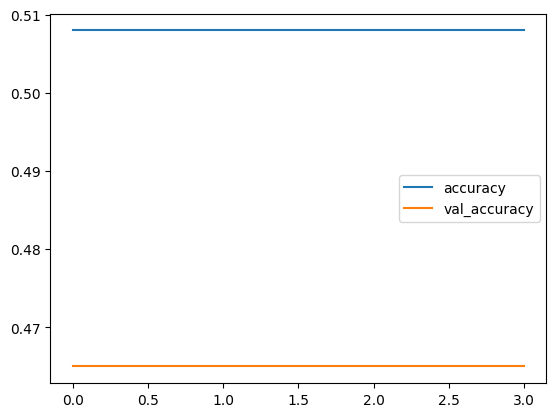

In [112]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'])

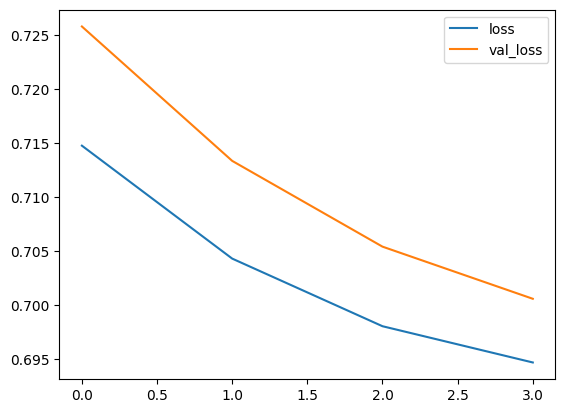

In [113]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])